# Ontogen for Power BI Semantic Models

This notebook demonstrates how `ontogen` can generate an **ontology-backed semantic resolution layer**
for a Power BI semantic model using the **IAEDU LLM backend** (no mocks).

For this Power BI use case, the graph deliberately separates:

- **`semantic_type`** — Metric, Dimension, TimeDimension, QueryPattern (fixed from model metadata)
- **`concept`** — Actual semantic concepts bound to PBI fields or DAX templates
- **`expression`** — Lexical aliases / surface forms that users type at query time

The `expression` layer is kept for resolution and relearning, but it is treated as a
**lexical mapping layer**, not as part of the domain ontology itself. In the package refactor,
lexical nodes are used to bind user language to concepts and are excluded from RDF serialization.

Cross-concept relationships (e.g. *"GrossMargin is sliceable by CustomerName"*) are injected from
Power BI's TOM relationship graph as **structural edges** that bypass LLM validation.

**Query patterns** (Aggregation, Ranking, Comparison, Trend, Forecast, etc.) are included as
first-class ontology concepts so the LLM can discover richer surface forms during expansion.

The notebook walks through:
1. **Mock TOM metadata** — simulating what the XMLA endpoint returns
2. **Seed conversion** — deterministically converting metadata into an ontogen seed
3. **Structural edge injection** — adding dimension-measure links from TOM relationships
4. **UCB1 expansion (10 iterations)** — discovering lexical aliases via IAEDU
5. **Graph-based query resolution** — resolving natural-language queries to DAX intent objects
6. **Session feedback + MCP-shaped proposals** — correcting wrong answers before any persistent update

In [13]:
import json
import logging
import os
import re
import time
from datetime import datetime, timezone

from ontogen import ChatGpt, Ontology, OntologyLevel
from ontogen.expansion_models import ExpansionRecord, GenerationHistory, PhaseRecord

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(name)s | %(message)s")

## Step 1 — Mock TOM Metadata

In production this comes from the XMLA endpoint via the Tabular Object Model (TOM).
It includes measures (with DAX expressions, descriptions, display folders, and synonyms),
dimension columns, and the relationship graph.

In [14]:
TOM_METADATA = {
    "dataset_name": "Professional Services Analytics",
    "measures": [
        {
            "name": "Revenue",
            "table": "Financials",
            "expression": "SUM(Financials[Amount])",
            "description": "Total revenue from all service engagements",
            "display_folder": "Revenue",
            "format_string": "$#,##0",
            "synonyms": ["sales", "revenue", "income"],
        },
        {
            "name": "Gross Margin %",
            "table": "Financials",
            "expression": "DIVIDE([Revenue] - [Direct Costs], [Revenue])",
            "description": "Gross profit as percentage of revenue",
            "display_folder": "Profitability",
            "format_string": "0.0%",
            "synonyms": ["margin", "GP%"],
        },
        {
            "name": "Net Profit",
            "table": "Financials",
            "expression": "[Revenue] - [Total Costs]",
            "description": "Net profit after all costs and overheads",
            "display_folder": "Profitability",
            "format_string": "$#,##0",
            "synonyms": ["profit", "net income", "bottom line"],
        },
        {
            "name": "Cost Per Job",
            "table": "Financials",
            "expression": "DIVIDE([Total Costs], [Job Count])",
            "description": "Average cost incurred per project or engagement",
            "display_folder": "Costs",
            "format_string": "$#,##0",
            "synonyms": ["job cost", "project cost"],
        },
        {
            "name": "Utilization Rate",
            "table": "Financials",
            "expression": "DIVIDE([Billable Hours], [Available Hours])",
            "description": "Percentage of available hours that are billable",
            "display_folder": "Performance",
            "format_string": "0.0%",
            "synonyms": ["utilization", "billable rate"],
        },
        {
            "name": "Budget",
            "table": "Financials",
            "expression": "SUM(Financials[Budget])",
            "description": "Budgeted revenue target for each engagement period",
            "display_folder": "Planning",
            "format_string": "$#,##0",
            "synonyms": ["budget", "target", "plan", "budgeted amount"],
        },
    ],
    "dimension_columns": [
        {"column": "'Customer'[Name]", "table": "Customer", "description": "Customer or client name", "synonyms": ["customer", "client", "account"]},
        {"column": "'Project'[Name]", "table": "Project", "description": "Project or job engagement name", "synonyms": ["project", "job", "engagement"]},
        {"column": "'ServiceLine'[Name]", "table": "ServiceLine", "description": "Service line or practice area", "synonyms": ["service line", "practice", "department"]},
        {"column": "'Region'[Name]", "table": "Region", "description": "Geographic region or territory", "synonyms": ["region", "territory", "geography"]}
    ],
    "time_columns": [
        {"column": "'Calendar'[Quarter]", "table": "Calendar", "description": "Fiscal quarter", "synonyms": ["quarter", "this quarter", "last quarter", "Q1", "Q2", "Q3", "Q4"]},
        {"column": "'Calendar'[Year]", "table": "Calendar", "description": "Fiscal year", "synonyms": ["year", "this year", "last year", "YTD"]}
    ],
    "relationships": [
        {"from_table": "Financials", "from_column": "CustomerKey", "to_table": "Customer", "to_column": "CustomerKey"},
        {"from_table": "Financials", "from_column": "ProjectKey", "to_table": "Project", "to_column": "ProjectKey"},
        {"from_table": "Financials", "from_column": "ServiceLineKey", "to_table": "ServiceLine", "to_column": "ServiceLineKey"},
        {"from_table": "Financials", "from_column": "RegionKey", "to_table": "Region", "to_column": "RegionKey"},
        {"from_table": "Financials", "from_column": "DateKey", "to_table": "Calendar", "to_column": "DateKey"},
        {"from_table": "Project", "from_column": "CustomerKey", "to_table": "Customer", "to_column": "CustomerKey"}
    ]
}

print(f"Model: {TOM_METADATA['dataset_name']}")
print(f"Measures: {len(TOM_METADATA['measures'])}")
print(f"Dimension columns: {len(TOM_METADATA['dimension_columns'])}")
print(f"Time columns: {len(TOM_METADATA['time_columns'])}")
print(f"Relationships: {len(TOM_METADATA['relationships'])}")


Model: Professional Services Analytics
Measures: 6
Dimension columns: 4
Time columns: 2
Relationships: 6


## Step 2 — Custom Level Schema for Power BI

The first two levels are ontology structure. The third level is a lexical mapping layer
used for resolution and relearning, not a domain ontology tier that should be serialized to RDF.

| Level | Name | Expandable | Purpose |
|-------|------|-----------|----------|
| 0 | `semantic_type` | **No** | Fixed categories: Metric, Dimension, TimeDimension, QueryPattern |
| 1 | `concept` | **Yes** | Actual PBI fields/patterns and query concepts |
| 2 | `expression` | **No** | Lexical aliases / surface forms users type — kept for resolution, excluded from RDF |

In [15]:
PBI_LEVEL_SCHEMA = [
    OntologyLevel(
        name="semantic_type",
        relation_to_parent=None,
        rdf_predicate=None,
        is_rdf_class=True,
        expandable=False,
        seed_key="type",
        children_key="concepts",
        plural_name="semantic types",
    ),
    OntologyLevel(
        name="concept",
        relation_to_parent="hasType",
        rdf_predicate="rdfs:subClassOf",
        is_rdf_class=True,
        expandable=True,
        seed_key="concept",
        children_key="expressions",
        plural_name="concepts",
    ),
    OntologyLevel(
        name="expression",
        relation_to_parent="expressedAs",
        rdf_predicate="rdf:type",
        is_rdf_class=False,
        expandable=False,
        seed_key="term",
        children_key=None,
        plural_name="expressions",
        is_lexical=True,
    ),
]

for level in PBI_LEVEL_SCHEMA:
    print(
        f"  {level.name:16s}  expandable={level.expandable!s:5s}  "
        f"lexical={level.is_lexical!s:5s}  seed_key={level.seed_key}"
    )

  semantic_type     expandable=False  lexical=False  seed_key=type
  concept           expandable=True   lexical=False  seed_key=concept
  expression        expandable=False  lexical=True   seed_key=term


## Step 3 — Convert TOM Metadata into an Ontogen Seed

Deterministic code — no LLM involved. PBI field bindings are preserved as custom node annotations.

In [16]:
def tom_to_seed(tom: dict) -> dict:
    """Convert TOM metadata into an ontogen seed dict."""

    def _make_concept_id(name: str) -> str:
        return re.sub(r"[^a-zA-Z0-9]", "", name.title().replace(" ", ""))

    def _make_expressions(synonyms: list[str]) -> list[dict]:
        return [{"term": s, "description": "TOM synonym"} for s in synonyms]

    metric_concepts = []
    for m in tom["measures"]:
        metric_concepts.append({
            "concept": _make_concept_id(m["name"]),
            "description": m["description"],
            "pbi_field": f"[{m['name']}]",
            "pbi_table": m["table"],
            "display_folder": m.get("display_folder", ""),
            "expressions": _make_expressions(m.get("synonyms", [])),
        })

    dim_concepts = []
    for d in tom["dimension_columns"]:
        dim_concepts.append({
            "concept": _make_concept_id(d["column"]),
            "description": d["description"],
            "pbi_field": d["column"],
            "pbi_table": d["table"],
            "expressions": _make_expressions(d.get("synonyms", [])),
        })

    time_concepts = []
    for t in tom["time_columns"]:
        time_concepts.append({
            "concept": _make_concept_id(t["column"]),
            "description": t["description"],
            "pbi_field": t["column"],
            "pbi_table": t["table"],
            "expressions": _make_expressions(t.get("synonyms", [])),
        })

    # Query patterns: analytical operations users can request.
    # Including these in the ontology enriches the semantic resolution layer —
    # the LLM can discover more surface forms for each pattern during expansion.
    query_patterns = [
        {
            "concept": "Aggregation",
            "description": "Summarize a metric, optionally grouped by dimensions",
            "dax_template": "SUMMARIZECOLUMNS",
            "expressions": [
                {"term": "show me", "description": "default aggregation intent"},
                {"term": "what is", "description": "question form"},
                {"term": "total", "description": "aggregation signal"},
                {"term": "how much", "description": "quantity question"},
            ],
        },
        {
            "concept": "Ranking",
            "description": "Rank dimension members by a metric (top/bottom N)",
            "dax_template": "TOPN",
            "expressions": [
                {"term": "top", "description": "ranking intent"},
                {"term": "best", "description": "positive ranking"},
                {"term": "worst", "description": "inverse ranking"},
                {"term": "which", "description": "selection / decomposition"},
            ],
        },
        {
            "concept": "Comparison",
            "description": "Compare a metric across two time periods",
            "dax_template": "CALCULATE + PREVIOUSPERIOD",
            "expressions": [
                {"term": "compare", "description": "explicit comparison"},
                {"term": "versus", "description": "comparison signal"},
                {"term": "year over year", "description": "YoY comparison"},
                {"term": "change", "description": "delta signal"},
            ],
        },
        {
            "concept": "Decomposition",
            "description": "Break down a metric by dimensions to explain variance",
            "dax_template": "SUMMARIZECOLUMNS (multi-dim)",
            "expressions": [
                {"term": "why", "description": "causal question"},
                {"term": "breakdown", "description": "decomposition signal"},
                {"term": "what is driving", "description": "variance explanation"},
            ],
        },
        {
            "concept": "NegativeFilter",
            "description": "Filter to items performing below zero or a threshold",
            "dax_template": "FILTER + negative condition",
            "expressions": [
                {"term": "losing money", "description": "negative profit filter"},
                {"term": "unprofitable", "description": "below-zero margin"},
                {"term": "below expectations", "description": "under-performance"},
                {"term": "underperforming", "description": "below target"},
            ],
        },
        {
            "concept": "Trend",
            "description": "Show how a metric evolves over time periods",
            "dax_template": "SUMMARIZECOLUMNS + time axis",
            "expressions": [
                {"term": "over time", "description": "temporal evolution"},
                {"term": "trending", "description": "trend analysis"},
                {"term": "month by month", "description": "monthly cadence"},
                {"term": "how has", "description": "historical question"},
            ],
        },
        {
            "concept": "Forecast",
            "description": "Project a metric forward using historical data",
            "dax_template": "CALCULATE + forecast logic",
            "expressions": [
                {"term": "forecast", "description": "explicit forecast"},
                {"term": "predict", "description": "prediction intent"},
                {"term": "expected", "description": "expectation projection"},
                {"term": "next quarter", "description": "future period reference"},
            ],
        },
        {
            "concept": "Threshold",
            "description": "Filter to items above or below a specific value or benchmark",
            "dax_template": "FILTER + threshold condition",
            "expressions": [
                {"term": "above", "description": "above-threshold filter"},
                {"term": "below", "description": "below-threshold filter"},
                {"term": "exceeding", "description": "over-threshold signal"},
                {"term": "more than", "description": "greater-than comparison"},
            ],
        },
        {
            "concept": "Contribution",
            "description": "Calculate the share or percentage contribution of a segment to the total",
            "dax_template": "DIVIDE + CALCULATE(ALL)",
            "expressions": [
                {"term": "share", "description": "proportion signal"},
                {"term": "percentage of", "description": "percent contribution"},
                {"term": "contribution", "description": "explicit contribution"},
                {"term": "how much of the total", "description": "share question"},
            ],
        },
    ]

    return {
        "domain": tom["dataset_name"],
        "taxonomy": [
            {"type": "Metric", "description": "Quantitative business measures", "concepts": metric_concepts},
            {"type": "Dimension", "description": "Categorical attributes for slicing data", "concepts": dim_concepts},
            {"type": "TimeDimension", "description": "Temporal attributes for filtering and trending", "concepts": time_concepts},
            {"type": "QueryPattern", "description": "Types of analytical operations users request", "concepts": query_patterns},
        ],
    }


seed = tom_to_seed(TOM_METADATA)
print(json.dumps(seed, indent=2)[:3000], "...")

{
  "domain": "Professional Services Analytics",
  "taxonomy": [
    {
      "type": "Metric",
      "description": "Quantitative business measures",
      "concepts": [
        {
          "concept": "Revenue",
          "description": "Total revenue from all service engagements",
          "pbi_field": "[Revenue]",
          "pbi_table": "Financials",
          "display_folder": "Revenue",
          "expressions": [
            {
              "term": "sales",
              "description": "TOM synonym"
            },
            {
              "term": "revenue",
              "description": "TOM synonym"
            },
            {
              "term": "income",
              "description": "TOM synonym"
            }
          ]
        },
        {
          "concept": "GrossMargin",
          "description": "Gross profit as percentage of revenue",
          "pbi_field": "[Gross Margin %]",
          "pbi_table": "Financials",
          "display_folder": "Profitability",
       

## Step 4 — Create Ontology with IAEDU Agent

Uses the IAEDU backend to drive real LLM expansion. The API key is loaded from `.env` via `dotenv`.
Endpoint and channel ID default to the standard IAEDU agent.

In [17]:
IAEDU_ENDPOINT = os.getenv(
    "IAEDU_ENDPOINT",
    "https://api.iaedu.pt/agent-chat//api/v1/agent/cmamvd3n40000c801qeacoad2/stream",
)
IAEDU_CHANNEL_ID = os.getenv("IAEDU_CHANNEL_ID", "cmj1i57292iz9lq01goukbuuv")

agent = ChatGpt(
    provider="iaedu",
    endpoint=IAEDU_ENDPOINT,
    channel_id=IAEDU_CHANNEL_ID,
    timeout=60,
    min_request_interval_seconds=1.0,
    max_concurrent_requests=1,
)

print(f"Provider: {agent.provider}")
print(f"Request policy: {agent.describe_request_policy()}")

2026-04-13 09:22:11,466 | INFO | ontogen.llm_client | Initialized iaedu client (provider=iaedu, max_concurrent_requests=1, min_request_interval_seconds=1.00)


Provider: iaedu
Request policy: provider=iaedu, max_concurrent_requests=1, min_request_interval_seconds=1.00


In [18]:
onto = Ontology(
    domain=seed["domain"],
    scope_description="Professional services firm: projects, customers, financials",
    agent=agent,
    level_schema=PBI_LEVEL_SCHEMA,
    similarity_threshold=85,
    cross_link_threshold=95,
    candidates_per_iteration=3,
    max_iterations=100,
    exploration_constant=0.7,
    max_workers=2,
    class_discovery_interval=10,
)

onto.seed = seed
onto.create_seed_ontology()

print(f"Graph: {onto.ontology_graph.number_of_nodes()} nodes, {onto.ontology_graph.number_of_edges()} edges")
print()
for node_id, attrs in onto.ontology_graph.nodes(data=True):
    pbi_field = attrs.get("pbi_field")
    if pbi_field:
        print(f"  {node_id:25s}  pbi_field={pbi_field:25s}  level={attrs['level']}")

2026-04-13 09:22:11,482 | INFO | ontogen.ontology | Created seed ontology with 99 nodes


Graph: 99 nodes, 95 edges

  Revenue                    pbi_field=[Revenue]                  level=concept
  GrossMargin                pbi_field=[Gross Margin %]           level=concept
  NetProfit                  pbi_field=[Net Profit]               level=concept
  CostPerJob                 pbi_field=[Cost Per Job]             level=concept
  UtilizationRate            pbi_field=[Utilization Rate]         level=concept
  Budget                     pbi_field=[Budget]                   level=concept
  CustomerName               pbi_field='Customer'[Name]           level=concept
  ProjectName                pbi_field='Project'[Name]            level=concept
  ServicelineName            pbi_field='ServiceLine'[Name]        level=concept
  RegionName                 pbi_field='Region'[Name]             level=concept
  CalendarQuarter            pbi_field='Calendar'[Quarter]        level=concept
  CalendarYear               pbi_field='Calendar'[Year]           level=concept


## Step 5 — Inject Structural and Semantic Edges

> Structural edges come directly from TOM relationships.
> Semantic edges capture analytical meaning that should be searchable in the ontology.

Edge types:
- `sliceable_by` — this metric can be grouped by this dimension
- `filterable_by` — this metric can be filtered by this time dimension
- `actual_vs_target` — this metric has a benchmark/plan counterpart
- `comparable_over_time` — this metric participates in period comparisons
- `supports_query_pattern` — this metric neighborhood supports a query pattern
- `derived_from` / `contribution_of` — added when derived metrics are materialized later

In [19]:
import importlib
import ontogen.pbi_semantics
importlib.reload(ontogen.pbi_semantics)
from ontogen.pbi_semantics import inject_pbi_semantic_relations


def tom_relationships_to_edges(tom: dict, seed: dict) -> list[dict]:
    reachable: dict[str, set[str]] = {}
    for rel in tom["relationships"]:
        reachable.setdefault(rel["from_table"], set()).add(rel["to_table"])

    table_to_dim_concepts: dict[str, list[str]] = {}
    for branch in seed["taxonomy"]:
        if branch["type"] in ("Dimension", "TimeDimension"):
            for c in branch["concepts"]:
                tbl = c.get("pbi_table", "")
                table_to_dim_concepts.setdefault(tbl, []).append(c["concept"])

    time_tables = {
        c.get("pbi_table")
        for branch in seed["taxonomy"]
        if branch["type"] == "TimeDimension"
        for c in branch["concepts"]
    }

    edges = []
    for branch in seed["taxonomy"]:
        if branch["type"] != "Metric":
            continue
        for measure in branch["concepts"]:
            measure_table = measure.get("pbi_table", "")
            for dim_table in reachable.get(measure_table, set()):
                for dim_concept in table_to_dim_concepts.get(dim_table, []):
                    rel_type = "filterable_by" if dim_table in time_tables else "sliceable_by"
                    edges.append(
                        {
                            "source": measure["concept"],
                            "target": dim_concept,
                            "relation": rel_type,
                        }
                    )

    # Transitive paths: Project -> Customer
    for rel in tom["relationships"]:
        if rel["from_table"] != "Financials":
            from_table = rel["from_table"]
            to_table = rel["to_table"]
            for branch in seed["taxonomy"]:
                if branch["type"] != "Metric":
                    continue
                for measure in branch["concepts"]:
                    m_table = measure.get("pbi_table", "")
                    if from_table in reachable.get(m_table, set()):
                        for dim_concept in table_to_dim_concepts.get(to_table, []):
                            edge = {
                                "source": measure["concept"],
                                "target": dim_concept,
                                "relation": "sliceable_by",
                            }
                            if edge not in edges:
                                edges.append(edge)
    return edges


structural_edges = tom_relationships_to_edges(TOM_METADATA, seed)
added = onto.add_structural_edges(structural_edges)
semantic_added = inject_pbi_semantic_relations(onto)
print(f"Injected {added} structural edges and {semantic_added} semantic relation edges.\n")
print("Structural edges:\n")
for e in structural_edges:
    print(f"  {e['source']:20s} --{e['relation']:14s}--> {e['target']}")

semantic_examples = []
for source, target, attrs in sorted(onto.ontology_graph.edges(data=True)):
    relation_names = []
    if attrs.get("relation") in {
        "actual_vs_target",
        "comparable_over_time",
        "supports_query_pattern",
        "derived_from",
        "contribution_of",
    }:
        relation_names.append(attrs["relation"])
    for name in attrs.get("semantic_relations", []) or []:
        if name not in relation_names:
            relation_names.append(name)
    if relation_names:
        semantic_examples.append(
            f"  {source:20s} --{', '.join(relation_names):22s}--> {target}"
        )

print("\nSample semantic relation edges:\n")
for line in semantic_examples[:20]:
    print(line)
if len(semantic_examples) > 20:
    print(f"  ... {len(semantic_examples) - 20} more semantic edges")

2026-04-13 09:22:11,527 | INFO | ontogen.ontology | Injected structural edge: 'Revenue' --filterable_by--> 'CalendarQuarter'
2026-04-13 09:22:11,528 | INFO | ontogen.ontology | Injected structural edge: 'Revenue' --filterable_by--> 'CalendarYear'
2026-04-13 09:22:11,529 | INFO | ontogen.ontology | Injected structural edge: 'Revenue' --sliceable_by--> 'RegionName'
2026-04-13 09:22:11,529 | INFO | ontogen.ontology | Injected structural edge: 'Revenue' --sliceable_by--> 'ProjectName'
2026-04-13 09:22:11,531 | INFO | ontogen.ontology | Injected structural edge: 'Revenue' --sliceable_by--> 'CustomerName'
2026-04-13 09:22:11,532 | INFO | ontogen.ontology | Injected structural edge: 'Revenue' --sliceable_by--> 'ServicelineName'
2026-04-13 09:22:11,532 | INFO | ontogen.ontology | Injected structural edge: 'GrossMargin' --filterable_by--> 'CalendarQuarter'
2026-04-13 09:22:11,533 | INFO | ontogen.ontology | Injected structural edge: 'GrossMargin' --filterable_by--> 'CalendarYear'
2026-04-13 09:

Injected 36 structural edges and 43 semantic relation edges.

Structural edges:

  Revenue              --filterable_by --> CalendarQuarter
  Revenue              --filterable_by --> CalendarYear
  Revenue              --sliceable_by  --> RegionName
  Revenue              --sliceable_by  --> ProjectName
  Revenue              --sliceable_by  --> CustomerName
  Revenue              --sliceable_by  --> ServicelineName
  GrossMargin          --filterable_by --> CalendarQuarter
  GrossMargin          --filterable_by --> CalendarYear
  GrossMargin          --sliceable_by  --> RegionName
  GrossMargin          --sliceable_by  --> ProjectName
  GrossMargin          --sliceable_by  --> CustomerName
  GrossMargin          --sliceable_by  --> ServicelineName
  NetProfit            --filterable_by --> CalendarQuarter
  NetProfit            --filterable_by --> CalendarYear
  NetProfit            --sliceable_by  --> RegionName
  NetProfit            --sliceable_by  --> ProjectName
  NetProfit      

## Step 6 — UCB1 Expansion

UCB1 selects concept nodes to expand. For each, the IAEDU LLM generates candidate expressions
validated by similarity before being added to the graph.

**Note:** Expansion adds new *expressions* (synonyms) under existing concepts. It cannot create
new concepts or derived metrics — that’s the job of the query-driven feedback loop (Step 8).

In [20]:
NUM_ITERATIONS = 100

# Initialize generation history for the manual expansion loop
onto.history = GenerationHistory(
    domain=onto.domain,
    started_at=datetime.now(timezone.utc).isoformat(),
    config={
        "exploration_constant": onto.exploration_constant,
        "max_iterations": NUM_ITERATIONS,
        "similarity_threshold": onto.similarity_threshold,
        "candidates_per_iteration": onto.candidates_per_iteration,
        "cross_link_threshold": onto.cross_link_threshold,
    },
)

pre_nodes = onto.ontology_graph.number_of_nodes()
pre_edges = onto.ontology_graph.number_of_edges()
pipeline_start = time.monotonic()

print(f"Before expansion: {pre_nodes} nodes, {pre_edges} edges")
print("=" * 70)

for i in range(NUM_ITERATIONS):
    result = onto.expand_ontology()
    selected = result.get("node", "?")
    generated = result.get("candidates_generated", 0)
    accepted = result.get("candidates_accepted", 0)
    reward = result.get("reward", 0.0)
    acceptance_rate = accepted / generated if generated > 0 else 0.0

    onto.history.expansion_records.append(ExpansionRecord(
        iteration=i + 1,
        node_expanded=selected,
        candidates_generated=generated,
        candidates_accepted=accepted,
        reward=reward,
        cumulative_nodes=onto.ontology_graph.number_of_nodes(),
        cumulative_edges=onto.ontology_graph.number_of_edges(),
        acceptance_rate=acceptance_rate,
        plateau_count=0,
        stagnation_count=0,
        elapsed_seconds=time.monotonic() - pipeline_start,
    ))

    print(f"  Iter {i+1:2d}: expanded '{selected:20s}' | generated={generated}, accepted={accepted}, reward={reward:.2f}")

post_nodes = onto.ontology_graph.number_of_nodes()
post_edges = onto.ontology_graph.number_of_edges()
expansion_duration = time.monotonic() - pipeline_start

# Finalize history
onto.history.completed_at = datetime.now(timezone.utc).isoformat()
onto.history.total_iterations = NUM_ITERATIONS
onto.history.final_nodes = post_nodes
onto.history.final_edges = post_edges
onto.history.termination_reason = "max_iterations"
onto.history.phases.append(PhaseRecord(
    phase=4, name="UCB1 expansion", duration_seconds=expansion_duration,
    details={"iterations": NUM_ITERATIONS},
))

print("=" * 70)
print(f"After expansion: {post_nodes} nodes (+{post_nodes - pre_nodes}), {post_edges} edges (+{post_edges - pre_edges})")

2026-04-13 09:22:11,578 | INFO | ontogen.ontology | Selected unvisited expandable node: Revenue
2026-04-13 09:22:11,580 | INFO | ontogen.ontology | Expanding node 'Revenue'


Before expansion: 99 nodes, 162 edges


2026-04-13 09:22:13,406 | INFO | ontogen.llm_client | [IAEDU #1] 'iaedu-chat' completed in 1.83s (slot_wait=0.00s, throttle_wait=0.00s, events=76, output_chars=358)
2026-04-13 09:22:13,407 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Revenue'
2026-04-13 09:22:13,408 | INFO | ontogen.ontology | Generated 3 candidates for 'Revenue'
2026-04-13 09:22:13,408 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Revenue' (threshold=85.0%)
2026-04-13 09:22:13,409 | INFO | ontogen.ontology | [Phase 4 candidate validation for Revenue] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=1, min_request_interval_seconds=1.00
2026-04-13 09:22:13,410 | INFO | ontogen.ontology | [Phase 4 candidate validation for Revenue] Cache miss: evaluating similarity(Revenue, total billings)
2026-04-13 09:22:13,411 | INFO | ontogen.ontology | [Phase 4 candidate validation for Revenue] Cache miss: evaluating similarity(Revenue, engag

  Iter  1: expanded 'Revenue             ' | generated=3, accepted=3, reward=0.85


2026-04-13 09:22:30,881 | INFO | ontogen.llm_client | [IAEDU #14] 'iaedu-chat' completed in 1.14s (slot_wait=0.00s, throttle_wait=0.21s, events=84, output_chars=397)
2026-04-13 09:22:30,883 | INFO | ontogen.ontology | Parsed 3 candidates for node 'GrossMargin'
2026-04-13 09:22:30,884 | INFO | ontogen.ontology | Generated 3 candidates for 'GrossMargin'
2026-04-13 09:22:30,885 | INFO | ontogen.ontology | Validating 3 candidates for parent 'GrossMargin' (threshold=85.0%)
2026-04-13 09:22:30,886 | INFO | ontogen.ontology | [Phase 4 candidate validation for GrossMargin] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=1, min_request_interval_seconds=1.00
2026-04-13 09:22:30,888 | INFO | ontogen.ontology | [Phase 4 candidate validation for GrossMargin] Cache miss: evaluating similarity(GrossMargin, ProfitabilityRatio)
2026-04-13 09:22:30,890 | INFO | ontogen.ontology | [Phase 4 candidate validation for GrossMargin] Cache miss: eva

...

  Iter 98: expanded 'CustomerName        ' | generated=3, accepted=0, reward=0.00


2026-04-13 10:08:03,820 | INFO | ontogen.llm_client | [IAEDU #1136] 'iaedu-chat' completed in 3.94s (slot_wait=0.00s, throttle_wait=0.00s, events=87, output_chars=414)
2026-04-13 10:08:03,821 | INFO | ontogen.ontology | Parsed 3 candidates for node 'ProjectName'
2026-04-13 10:08:03,821 | INFO | ontogen.ontology | Generated 3 candidates for 'ProjectName'
2026-04-13 10:08:03,822 | INFO | ontogen.ontology | Validating 3 candidates for parent 'ProjectName' (threshold=85.0%)
2026-04-13 10:08:03,823 | INFO | ontogen.ontology | Rejected candidate 'assignment' for parent 'ProjectName': similarity=75.0% < 85.0%
2026-04-13 10:08:03,823 | INFO | ontogen.ontology | Rejected candidate 'workstream' for parent 'ProjectName': similarity=65.0% < 85.0%
2026-04-13 10:08:03,824 | INFO | ontogen.ontology | Rejected candidate 'initiative' for parent 'ProjectName': similarity=75.0% < 85.0%
2026-04-13 10:08:03,825 | INFO | ontogen.ontology | Validated candidates: 0/3 accepted
2026-04-13 10:08:03,825 | INFO | 

  Iter 99: expanded 'ProjectName         ' | generated=3, accepted=0, reward=0.00


2026-04-13 10:08:05,046 | INFO | ontogen.llm_client | [IAEDU #1137] 'iaedu-chat' completed in 1.22s (slot_wait=0.00s, throttle_wait=0.00s, events=81, output_chars=332)
2026-04-13 10:08:05,047 | INFO | ontogen.ontology | Parsed 3 candidates for node 'Threshold'
2026-04-13 10:08:05,048 | INFO | ontogen.ontology | Generated 3 candidates for 'Threshold'
2026-04-13 10:08:05,049 | INFO | ontogen.ontology | Validating 3 candidates for parent 'Threshold' (threshold=85.0%)
2026-04-13 10:08:05,049 | INFO | ontogen.ontology | [Phase 4 candidate validation for Threshold] Starting similarity batch: total_pairs=3, uncached_pairs=3, workers=2, provider=iaedu, max_concurrent_requests=1, min_request_interval_seconds=1.00
2026-04-13 10:08:05,050 | INFO | ontogen.ontology | [Phase 4 candidate validation for Threshold] Cache miss: evaluating similarity(Threshold, greater than)
2026-04-13 10:08:05,052 | INFO | ontogen.ontology | [Phase 4 candidate validation for Threshold] Cache miss: evaluating similarity

  Iter 100: expanded 'Threshold           ' | generated=3, accepted=2, reward=0.57
After expansion: 354 nodes (+255), 417 edges (+255)


In [21]:
print("Expression coverage per concept:\n")
for node_id, attrs in sorted(onto.ontology_graph.nodes(data=True), key=lambda x: x[1].get("level", "")):
    if attrs.get("level") != "concept":
        continue
    children = [
        onto.ontology_graph.nodes[c].get("term", c)
        for c in onto.ontology_graph.successors(node_id)
        if onto.ontology_graph.nodes[c].get("level") == "expression"
    ]
    pbi = attrs.get("pbi_field", attrs.get("dax_template", ""))
    visits = attrs.get("n_visits", 0)
    print(f"  {node_id:22s} ({pbi:30s})  visits={visits}  expressions={children}")

Expression coverage per concept:

  Revenue                ([Revenue]                     )  visits=6  expressions=['sales', 'revenue', 'income', 'total billings', 'engagement earnings', 'service income', 'client revenue', 'project earnings', 'service revenue', 'contract revenue', 'client billings', 'service engagement income', 'consulting fees', 'professional service earnings', 'client engagement revenue', 'consulting revenue', 'service contract earnings', 'client engagement income', 'service delivery revenue', 'client service proceeds', 'engagement-derived income']
  GrossMargin            ([Gross Margin %]              )  visits=7  expressions=['margin', 'GP%', 'ProfitabilityRatio', 'RevenueEfficiency', 'ProfitMarginPercentage', 'EarningsRatio', 'RevenueMargin', 'ProfitabilityPercentage', 'RevenueProfitRatio', 'ProfitabilityIndex', 'EarningsToRevenuePercentage', 'RevenueProfitMargin', 'ProfitToRevenueRatio', 'GrossProfitPercentage', 'RevenueProfitEfficiency', 'GrossProfitRatio', 'Pr

  Ontology Generation Summary
  Domain:            Professional Services Analytics
  Started:           2026-04-13T09:22:11.577987+00:00
  Completed:         2026-04-13T10:08:23.017331+00:00
  Iterations:        100
  Final nodes:       354
  Final edges:       417
  RDF triples:       0
  Early terminated:  False
  Reason:            max_iterations
────────────────────────────────────────────────────────────
  Phase Timing:
    4. UCB1 expansion                  2561.1s
────────────────────────────────────────────────────────────
  Expansion Stats:
    Avg reward:        0.755
    Total generated:   291
    Total accepted:    257
    Overall accept %:  88.3%


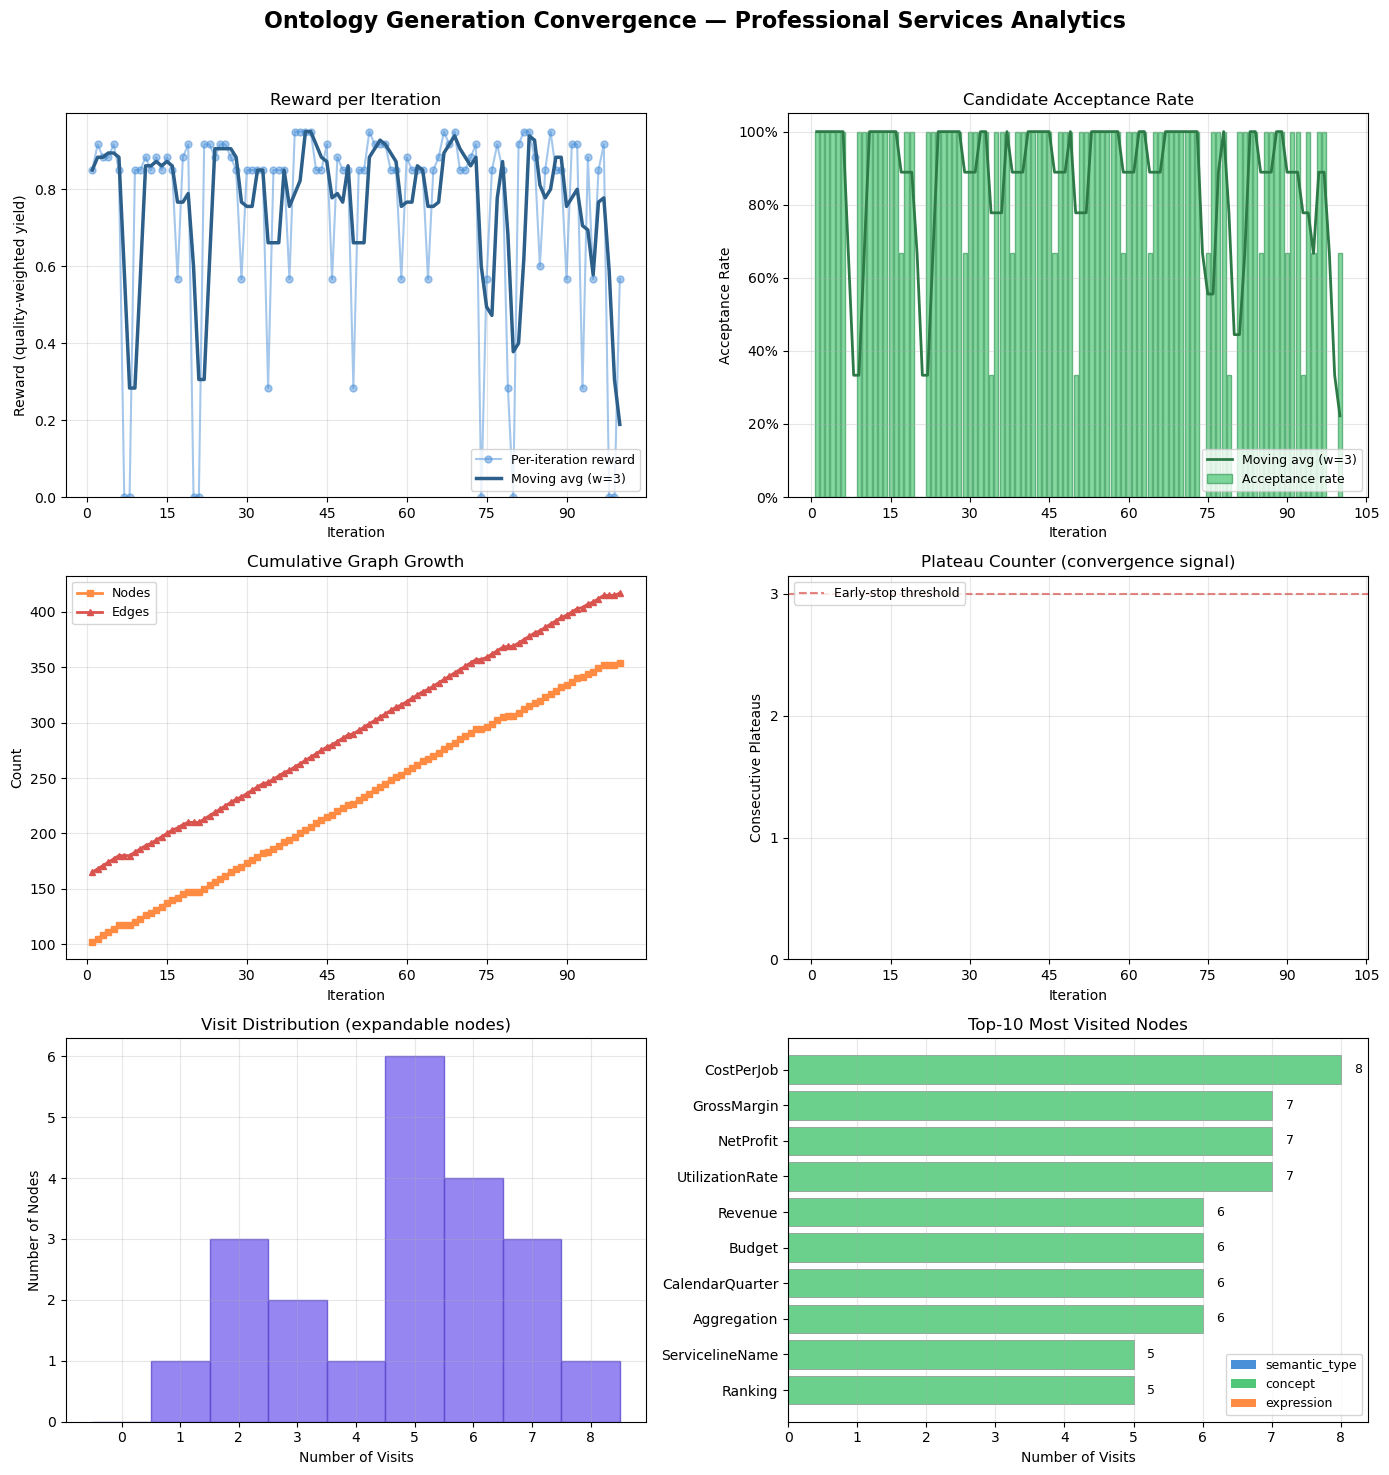


Pipeline complete!
Final graph: 354 nodes, 417 edges


In [22]:
# Post-run audit
print(onto.history.summary())      # formatted summary
df = onto.history.to_dataframe()   # pandas DataFrame
onto.plot_convergence()            # matplotlib convergence charts

print(f"\nPipeline complete!")
print(f"Final graph: {onto.ontology_graph.number_of_nodes()} nodes, {onto.ontology_graph.number_of_edges()} edges")

## Step 6b — RDF Build & Interactive HTML Export

Build the RDF graph from the expanded DiGraph and export a full-page interactive visualization.

In [23]:
# Build RDF graph from the expanded DiGraph and export interactive HTML visualization
onto.build_ontology()
print(f"RDF graph: {len(onto.rdf)} triples")

html_path = onto.visualize_interactive(output_path="ontology_pbi.html")
print(f"Interactive visualization saved to: {html_path}")

2026-04-13 10:08:25,482 | INFO | ontogen.ontology | RDF ontology built successfully: 138 triples


RDF graph: 138 triples
ontology_pbi.html


2026-04-13 10:08:25,794 | INFO | ontogen.ontology | Interactive RDF ontology graph saved to /workspaces/thesis-llml-onthology/notebooks/ontology_pbi.html


Interactive visualization saved to: /workspaces/thesis-llml-onthology/notebooks/ontology_pbi.html


## Step 7 — Query Resolution

> Resolution is now two-layered: lexical alias lookup first, then relation-aware ontology search.

Given NER-like token extraction, the resolver now:
1. Matches tokens to lexical alias nodes
2. Walks up to the parent concept for PBI field binding
3. Expands the candidate set through semantic relations such as `actual_vs_target`, `derived_from`, `comparable_over_time`, and `supports_query_pattern`
4. Follows `sliceable_by` / `filterable_by` edges to validate dimension use
5. Applies any session-scoped feedback override before proposing a persistent ontology update

The graph retrieves the relevant neighborhood; the planner still composes missing derived metrics when no materialized concept exists yet.

In [24]:
# Reload resolution helpers to pick up lexical alias handling and shared PBI semantics
import importlib
import ontogen.pbi_semantics
import ontogen.resolution
importlib.reload(ontogen.resolution)
importlib.reload(ontogen.pbi_semantics)
from ontogen.mcp_schema import build_clarification_request
from ontogen.pbi_semantics import (
    describe_metric_binding,
    find_relation_metric_matches,
    metric_resolution_specificity,
)
from ontogen.resolution import ResolutionMixin
onto.resolve_expression = ResolutionMixin.resolve_expression.__get__(onto)
onto._walk_to_ancestor = ResolutionMixin._walk_to_ancestor.__get__(onto)
print("Reloaded resolution module with lexical alias support and relation-aware PBI semantics")

MODEL_METRIC_FIELDS = {f"[{measure['name']}]" for measure in TOM_METADATA["measures"]}
PROFITABILITY_PHRASES = frozenset({"profitable", "profitability"})
PROFITABILITY_CANDIDATE_CONCEPTS = ("GrossMargin", "NetProfit")
PROFITABILITY_DEFAULT_ORDER = {"GrossMargin": 0, "NetProfit": 1}
PROFITABILITY_RATIONALES = {
    "GrossMargin": "Gross margin answers profitability as a rate or percentage.",
    "NetProfit": "Net profit answers profitability as an absolute amount after costs.",
}


def build_profitability_clarification_request(query_text):
    """Build a clarification payload for ambiguous profitability questions."""
    options = []
    for concept_node in PROFITABILITY_CANDIDATE_CONCEPTS:
        if concept_node not in onto.ontology_graph:
            continue
        concept_attrs = dict(onto.ontology_graph.nodes[concept_node])
        metric_binding = describe_metric_binding(
            concept_attrs,
            model_metric_fields=sorted(MODEL_METRIC_FIELDS),
        )
        options.append(
            {
                "concept": concept_node,
                "semantic_type": "Metric",
                "label": metric_binding["label"],
                "confidence": 0.55 if concept_node == "GrossMargin" else 0.45,
                "rationale": PROFITABILITY_RATIONALES.get(
                    concept_node,
                    "Profitability candidate metric.",
                ),
            }
        )

    return build_clarification_request(
        query_text=query_text,
        ambiguous_span="profitable",
        role="metric",
        question=(
            "When you ask how profitable we were, do you mean profitability rate "
            "or absolute profit amount?"
        ),
        options=options,
    )



def resolve_query(onto, extracted_tokens, feedback_overrides=None):
    """Resolve tokens to intent using lexical and relation-aware ontology search."""
    feedback_overrides = feedback_overrides or {}

    type_priority = {
        "filter": ["Metric", "Dimension", "TimeDimension", "QueryPattern"],
        "metric": ["Metric", "QueryPattern", "Dimension", "TimeDimension"],
        "dimension": ["Dimension", "Metric", "TimeDimension", "QueryPattern"],
        "time": ["TimeDimension", "Metric", "Dimension", "QueryPattern"],
        "intent": ["QueryPattern", "Metric", "Dimension", "TimeDimension"],
    }

    def _get_semantic_type(concept_node):
        for parent in onto.ontology_graph.predecessors(concept_node):
            if onto.ontology_graph.nodes[parent].get("level") == "semantic_type":
                return onto.ontology_graph.nodes[parent].get("term", parent)
        return ""

    def _inject_override_matches(matches, token_text):
        """Allow session feedback to promote a concept even if the phrase was unseen."""
        override = feedback_overrides.get(token_text.strip().lower(), {})
        preferred = override.get("prefer_concepts", [])
        existing = {match["concept_node"] for match in matches}
        augmented = list(matches)

        for concept_node in preferred:
            if concept_node in existing or concept_node not in onto.ontology_graph:
                continue
            augmented.append(
                {
                    "expression_node": token_text.strip().lower(),
                    "concept_node": concept_node,
                    "concept_attrs": dict(onto.ontology_graph.nodes[concept_node]),
                    "path": [token_text.strip().lower(), concept_node],
                    "relation_reason": "session_override",
                }
            )
        return augmented

    def _inject_semantic_metric_hints(matches, token_text, role):
        """Inject governed metric candidates for phrases that imply a metric family."""
        normalized_text = token_text.strip().lower()
        if role != "metric":
            return matches
        if not any(phrase in normalized_text for phrase in PROFITABILITY_PHRASES):
            return matches

        existing = {match["concept_node"] for match in matches}
        augmented = list(matches)
        for concept_node in PROFITABILITY_CANDIDATE_CONCEPTS:
            if concept_node in existing or concept_node not in onto.ontology_graph:
                continue
            augmented.append(
                {
                    "expression_node": normalized_text,
                    "concept_node": concept_node,
                    "concept_attrs": dict(onto.ontology_graph.nodes[concept_node]),
                    "path": [normalized_text, concept_node],
                    "relation_reason": "semantic_hint:profitability",
                }
            )
        return augmented

    def _extend_matches(matches, extra_matches):
        seen = {match["concept_node"] for match in matches}
        augmented = list(matches)
        for match in extra_matches:
            if match["concept_node"] in seen:
                continue
            augmented.append(match)
            seen.add(match["concept_node"])
        return augmented

    def _rank_matches(matches, role, token_text):
        """Rank matches by feedback, relation evidence, semantic type, and local defaults."""
        priority = type_priority.get(role, type_priority["filter"])
        normalized_text = token_text.strip().lower()
        override = feedback_overrides.get(normalized_text, {})
        preferred = set(override.get("prefer_concepts", []))
        avoided = set(override.get("avoid_concepts", []))

        def sort_key(match):
            concept_node = match["concept_node"]
            semantic_type = _get_semantic_type(concept_node)
            try:
                priority_index = priority.index(semantic_type)
            except ValueError:
                priority_index = len(priority)

            feedback_rank = 1
            if concept_node in preferred:
                feedback_rank = 0
            elif concept_node in avoided:
                feedback_rank = 2

            relation_rank = 1 if match.get("relation_reason") else 0

            profitability_rank = 1
            if role == "metric" and any(
                phrase in normalized_text for phrase in PROFITABILITY_PHRASES
            ):
                profitability_rank = PROFITABILITY_DEFAULT_ORDER.get(concept_node, 2)

            metric_specificity = 1
            if role == "filter" and semantic_type == "Metric":
                metric_specificity = metric_resolution_specificity(
                    token_text,
                    role,
                    match["concept_attrs"],
                )

            return (
                feedback_rank,
                profitability_rank,
                relation_rank,
                priority_index,
                metric_specificity,
                concept_node,
            )

        return sorted(matches, key=sort_key)

    def _append_unique(entries, key, item):
        if item[key] not in {entry[key] for entry in entries}:
            entries.append(item)

    intent = {
        "metrics": [],
        "group_by": [],
        "time_filters": [],
        "query_patterns": [],
        "resolution_log": [],
    }

    for token in extracted_tokens:
        text, role = token["text"], token["role"]
        matches = onto.resolve_expression(text)
        matches = _inject_override_matches(matches, text)
        matches = _inject_semantic_metric_hints(matches, text, role)

        relation_result = {"matches": [], "evidence": []}
        if role == "filter":
            relation_result = find_relation_metric_matches(onto, text, intent)
            matches = _extend_matches(matches, relation_result["matches"])

        if not matches:
            intent["resolution_log"].append(f"  X '{text}' ({role}) -> NO MATCH")
            for evidence in relation_result["evidence"]:
                intent["resolution_log"].append(f"    relation search: {evidence}")
            continue

        ranked = _rank_matches(matches, role, text)
        best = ranked[0]
        concept = best["concept_node"]
        concept_attrs = best["concept_attrs"]
        pbi_field = concept_attrs.get("pbi_field", "")
        dax_template = concept_attrs.get("dax_template", "")

        semantic_type = _get_semantic_type(concept)

        log = f"  > '{text}' ({role}) -> '{best['expression_node']}' -> '{concept}' [{semantic_type}]"
        if pbi_field:
            log += f" pbi_field={pbi_field}"
        if dax_template:
            log += f" dax_template={dax_template}"
        override = feedback_overrides.get(text.strip().lower(), {})
        if concept in set(override.get("prefer_concepts", [])):
            reason = override.get("reason", "user correction")
            log += f" [session override: {reason}]"
        if best.get("relation_reason") and best["relation_reason"] != "session_override":
            reason_label = (
                "semantic hint"
                if best["relation_reason"].startswith("semantic_hint:")
                else "relation search"
            )
            log += f" [{reason_label}: {best['relation_reason']}]"
        if len(ranked) > 1:
            alt_strs = [
                f"{_get_semantic_type(match['concept_node'])}:{match['concept_node']}"
                for match in ranked[1:]
            ]
            log += f"  (also: {', '.join(alt_strs)})"
        intent["resolution_log"].append(log)
        for evidence in relation_result["evidence"]:
            intent["resolution_log"].append(f"    relation search: {evidence}")

        if semantic_type == "Metric" and pbi_field:
            metric_binding = describe_metric_binding(
                concept_attrs,
                model_metric_fields=sorted(MODEL_METRIC_FIELDS),
            )
            _append_unique(
                intent["metrics"],
                "concept",
                {
                    "field": metric_binding["field"],
                    "concept": concept,
                    "reference": metric_binding["reference"],
                    "dax_expression": metric_binding["dax_expression"],
                    "is_derived": metric_binding["is_derived"],
                    "label": metric_binding["label"],
                },
            )
        elif semantic_type == "Dimension" and pbi_field:
            _append_unique(
                intent["group_by"],
                "concept",
                {"field": pbi_field, "concept": concept},
            )
        elif semantic_type == "TimeDimension" and pbi_field:
            _append_unique(
                intent["time_filters"],
                "concept",
                {"field": pbi_field, "concept": concept},
            )
        elif semantic_type == "QueryPattern":
            _append_unique(
                intent["query_patterns"],
                "pattern",
                {"pattern": concept, "dax_template": dax_template},
            )

        if role == "filter":
            supplemental_patterns = []
            for match in ranked:
                match_type = _get_semantic_type(match["concept_node"])
                if match_type != "QueryPattern":
                    continue
                pattern = match["concept_node"]
                pattern_template = match["concept_attrs"].get("dax_template", "")
                _append_unique(
                    intent["query_patterns"],
                    "pattern",
                    {"pattern": pattern, "dax_template": pattern_template},
                )
                supplemental_patterns.append(pattern)
            if supplemental_patterns and semantic_type != "QueryPattern":
                intent["resolution_log"].append(
                    f"    -> supplemental query patterns from '{text}': {supplemental_patterns}"
                )

    if intent["metrics"]:
        metric_concept = intent["metrics"][0]["concept"]
        valid_dims = {
            item["node"]
            for item in onto.get_connected_concepts(metric_concept, relation="sliceable_by")
        }
        valid_time = {
            item["node"]
            for item in onto.get_connected_concepts(metric_concept, relation="filterable_by")
        }

        for dim in intent["group_by"]:
            is_valid = dim["concept"] in valid_dims
            dim["structurally_valid"] = is_valid
            intent["resolution_log"].append(
                f"  {'OK' if is_valid else 'XX'} {metric_concept} --sliceable_by--> {dim['concept']}: {is_valid}"
            )
        for time_filter in intent["time_filters"]:
            is_valid = time_filter["concept"] in valid_time
            time_filter["structurally_valid"] = is_valid
            intent["resolution_log"].append(
                f"  {'OK' if is_valid else 'XX'} {metric_concept} --filterable_by--> {time_filter['concept']}: {is_valid}"
            )

        patterns = {item["pattern"] for item in intent["query_patterns"]}
        needs_dims = patterns & {"Decomposition", "Ranking", "NegativeFilter"}
        if needs_dims and not intent["group_by"]:
            intent["resolution_log"].append(
                f"  !! Pattern(s) {needs_dims} need dimensions - auto-suggesting:"
            )
            for valid_dim in onto.get_connected_concepts(metric_concept, relation="sliceable_by"):
                field = valid_dim["attrs"].get("pbi_field", "")
                intent["group_by"].append(
                    {
                        "field": field,
                        "concept": valid_dim["node"],
                        "structurally_valid": True,
                        "auto_suggested": True,
                    }
                )
                intent["resolution_log"].append(
                    f"    -> {valid_dim['node']} ({field})"
                )

    return intent


def print_intent(intent):
    print("\nResolution log:")
    for line in intent["resolution_log"]:
        print(line)
    print("\nResolved intent:")
    print(f"  Metrics:        {[metric['label'] for metric in intent['metrics']]}")
    print(f"  Group by:       {[dim['field'] for dim in intent['group_by']]}")
    print(f"  Time filters:   {[flt['field'] for flt in intent['time_filters']]}")
    print(f"  Query patterns: {[pattern['pattern'] for pattern in intent['query_patterns']]}")

    if intent["metrics"]:
        metric_entry = intent["metrics"][0]
        metric_reference = metric_entry["reference"]
        dims = [
            dim["field"]
            for dim in intent["group_by"]
            if dim.get("structurally_valid", True)
        ]
        time_filters = intent["time_filters"]
        patterns = {pattern["pattern"] for pattern in intent["query_patterns"]}
        if metric_entry.get("is_derived"):
            print("\n  Derived metric definition:")
            print(f"    {metric_entry['field']} := {metric_entry['dax_expression']}")
        print("\n  DAX sketch:")
        if "Ranking" in patterns or "NegativeFilter" in patterns:
            cols = ", ".join(dims) if dims else "<needs dimension>"
            time_clause = f", {time_filters[0]['field']}" if time_filters else ""
            filter_predicate = "[Result] < 0" if "NegativeFilter" in patterns else "NOT ISBLANK([Result])"
            print("    EVALUATE")
            print("    FILTER(")
            print(f"      SUMMARIZECOLUMNS({cols}, \"Result\", {metric_reference}{time_clause}),")
            print(f"      {filter_predicate}")
            print("    )")
        else:
            cols = ", ".join(dims) if dims else ""
            comma = ", " if cols else ""
            time_clause = f"  -- filtered to {time_filters[0]['field']}" if time_filters else ""
            print("    EVALUATE")
            print(f"    SUMMARIZECOLUMNS({cols}{comma}\"Result\", {metric_reference}){time_clause}")


print("Query resolver ready (lexical + relation-aware multi-concept resolution)")

Reloaded resolution module with lexical alias support and relation-aware PBI semantics
Query resolver ready (lexical + relation-aware multi-concept resolution)


### Query 1: *"How profitable we were this quarter?"*

Profitability is ambiguous in this model: it could mean **gross margin** (rate) or
**net profit** (absolute amount). The resolver now defaults to `GrossMargin` for the demo,
but it also emits a clarification payload so an MCP client can ask the user which meaning
they intended before executing the final query.

In [25]:
print("=" * 70)
print('QUERY: "How profitable we were this quarter?"')
print("=" * 70)

tokens_q1 = [
    {"text": "profitability", "role": "metric"},
    {"text": "this quarter", "role": "time"},
]
intent_q1 = resolve_query(onto, tokens_q1)
print_intent(intent_q1)

clarification_request_q1 = build_profitability_clarification_request(
    "How profitable we were this quarter?"
)
print("\nClarification payload:")
print(json.dumps(clarification_request_q1, indent=2))

QUERY: "How profitable we were this quarter?"

Resolution log:
  > 'profitability' (metric) -> 'ProfitabilityRatio' -> 'GrossMargin' [Metric] pbi_field=[Gross Margin %]  (also: Metric:GrossMargin, Metric:GrossMargin, Metric:NetProfit, QueryPattern:NegativeFilter)
  > 'this quarter' (time) -> 'quarter' -> 'CalendarQuarter' [TimeDimension] pbi_field='Calendar'[Quarter]  (also: TimeDimension:CalendarQuarter)
  OK GrossMargin --filterable_by--> CalendarQuarter: True

Resolved intent:
  Metrics:        ['[Gross Margin %]']
  Group by:       []
  Time filters:   ["'Calendar'[Quarter]"]
  Query patterns: []

  DAX sketch:
    EVALUATE
    SUMMARIZECOLUMNS("Result", [Gross Margin %])  -- filtered to 'Calendar'[Quarter]

Clarification payload:
{
  "kind": "clarification_request",
  "query": "How profitable we were this quarter?",
  "ambiguous_span": "profitable",
  "role": "metric",
  "question": "When you ask how profitable we were, do you mean profitability rate or absolute profit amount?",
 

### Query 2: *"Which customers are we losing money?"*

In [26]:
print("=" * 70)
print('QUERY: "Which customers are we losing money?"')
print("=" * 70)

tokens_q2 = [
    {"text": "which", "role": "intent"},
    {"text": "customer", "role": "dimension"},
    {"text": "losing money", "role": "filter"},
    {"text": "profit", "role": "metric"},
]
intent_q2 = resolve_query(onto, tokens_q2)
print_intent(intent_q2)

QUERY: "Which customers are we losing money?"

Resolution log:
  > 'which' (intent) -> 'which' -> 'Ranking' [QueryPattern] dax_template=TOPN
  > 'customer' (dimension) -> 'customer' -> 'CustomerName' [Dimension] pbi_field='Customer'[Name]
  > 'losing money' (filter) -> 'losing money' -> 'NegativeFilter' [QueryPattern] dax_template=FILTER + negative condition
  > 'profit' (metric) -> 'ProfitabilityRatio' -> 'GrossMargin' [Metric] pbi_field=[Gross Margin %]  (also: Metric:GrossMargin, Metric:GrossMargin, Metric:GrossMargin, Metric:GrossMargin, Metric:GrossMargin, Metric:GrossMargin, Metric:GrossMargin, Metric:GrossMargin, Metric:GrossMargin, Metric:GrossMargin, Metric:GrossMargin, Metric:GrossMargin, Metric:GrossMargin, Metric:GrossMargin, Metric:NetProfit, Metric:NetProfit, Metric:NetProfit, Metric:NetProfit, Metric:NetProfit, Metric:NetProfit, Metric:NetProfit, QueryPattern:NegativeFilter, QueryPattern:NegativeFilter)
  OK GrossMargin --sliceable_by--> CustomerName: True

Resolved inte

### Query 3: *"Which jobs are performing below expectations?"*

TOM has a raw **Budget** metric but no derived variance metric yet. The shared
Power BI planner now tries three outcomes in order:

1. An existing derived metric already covers the intent, so the resolver prefers it
2. No such metric exists, so the deterministic planner creates `BudgetVariance = [Revenue] - [Budget]`
3. If no deterministic rule applies, the LLM fallback still proposes `map_existing` or `create_new`

Either way, the system should resolve *"below expectations"* to the right **metric meaning**,
not just to a generic negative-filter pattern.

In [27]:
print("=" * 70)
print('QUERY: "Which jobs are performing below expectations?"')
print("=" * 70)

tokens_q3 = [
    {"text": "which", "role": "intent"},
    {"text": "job", "role": "dimension"},
    {"text": "below expectations", "role": "filter"},
]
intent_q3 = resolve_query(onto, tokens_q3)
print_intent(intent_q3)

QUERY: "Which jobs are performing below expectations?"

Resolution log:
  > 'which' (intent) -> 'which' -> 'Ranking' [QueryPattern] dax_template=TOPN
  > 'job' (dimension) -> 'job' -> 'ProjectName' [Dimension] pbi_field='Project'[Name]  (also: Metric:CostPerJob)
  > 'below expectations' (filter) -> 'below expectations' -> 'NegativeFilter' [QueryPattern] dax_template=FILTER + negative condition  (also: QueryPattern:Threshold)
    relation search: relation actual_vs_target links Revenue to Budget, but no derived metric is materialized yet

Resolved intent:
  Metrics:        []
  Group by:       ["'Project'[Name]"]
  Time filters:   []
  Query patterns: ['Ranking', 'NegativeFilter', 'Threshold']


## Step 8 — Query-Driven Ontology Feedback

When multi-concept resolution still produces a semantic gap, the notebook now uses three layers in order:

1. **Lexical alias search** — direct phrase-to-concept matching
2. **Relation-aware ontology search** — traverse `actual_vs_target`, `derived_from`, `comparable_over_time`, `contribution_of`, `supports_query_pattern`
3. **Procedural planner** — compose a missing derived metric only when the graph finds the right ingredients but no materialized concept exists yet

This keeps semantic knowledge inside the ontology search while preserving a procedural DAX composition layer.

Shared payloads used in this notebook:

- `clarification_request` / `clarification_response`
- `correction_request` / `correction_response`
- `ontology_update_proposal`

Deterministic repair families still run before any LLM fallback:

- **Actual-vs-target variance**: e.g. Revenue vs Budget, Revenue vs Plan, Actual vs Target
- **Period-over-period variance**: e.g. year over year, quarter over quarter, previous-period change
- **Share-of-total / contribution**: e.g. percentage of total, contribution, mix

In [28]:
import importlib
import ontogen.pbi_semantics
importlib.reload(ontogen.pbi_semantics)
from ontogen.pbi_semantics import detect_pbi_resolution_gap


gap = detect_pbi_resolution_gap(onto, intent_q3, tokens_q3)
print("Gap analysis for Query 3:")
print(f"  has_gap:           {gap['has_gap']}")
print(f"  gap_type:          {gap['gap_type']}")
print(f"  mismatched_filters:{gap['mismatched_filters']}")
print(f"  unresolved:        {gap['unresolved_tokens']}")
if gap["context"].get("patterns_matched"):
    print(f"  patterns:          {gap['context']['patterns_matched']}")
if gap["context"].get("resolved_metrics"):
    print(f"  resolved metrics:  {[metric['concept'] for metric in gap['context']['resolved_metrics']]}")
if gap["context"].get("deterministic_proposal"):
    deterministic = gap["context"]["deterministic_proposal"]
    print("  deterministic proposal:")
    print(f"    - action:   {deterministic['action']}")
    print(f"    - concept:  {deterministic['concept']}")
    print(f"    - dax:      {deterministic['dax_expression']}")
if gap["context"].get("available_metrics"):
    print("  available metrics:")
    for metric in gap["context"]["available_metrics"]:
        print(
            f"    - {metric['concept']:20s} field={metric['pbi_field']:20s} dax={metric['dax_expression'] or '<base>'}"
        )

Gap analysis for Query 3:
  has_gap:           True
  gap_type:          no_metric
  mismatched_filters:[{'token': 'below expectations', 'resolved_as': 'QueryPattern', 'missing': 'Metric'}, {'token': 'below expectations', 'resolved_as': 'none', 'missing': 'BudgetVariance'}]
  unresolved:        []
  patterns:          ['Ranking', 'NegativeFilter', 'Threshold']
  deterministic proposal:
    - action:   create_new
    - concept:  BudgetVariance
    - dax:      [Revenue] - [Budget]
  available metrics:
    - Revenue              field=[Revenue]            dax=<base>
    - GrossMargin          field=[Gross Margin %]     dax=<base>
    - NetProfit            field=[Net Profit]         dax=<base>
    - CostPerJob           field=[Cost Per Job]       dax=<base>
    - UtilizationRate      field=[Utilization Rate]   dax=<base>
    - Budget               field=[Budget]             dax=<base>


In [29]:
from ontogen.pbi_semantics import diagnose_and_propose_pbi


if gap["has_gap"]:
    proposal = diagnose_and_propose_pbi(
        onto,
        gap,
        "Which jobs are performing below expectations?",
    )
    if proposal.get("diagnosed_by") == "deterministic_rule":
        print("Deterministic planner proposal:")
        print(json.dumps(proposal, indent=2))
    print("=" * 70)
    print("PROPOSAL:")
    print(f"  Action:      {proposal.get('action')}")
    print(f"  Concept:     {proposal.get('concept')}")
    print(f"  PBI field:   {proposal.get('pbi_field')}")
    print(f"  DAX:         {proposal.get('dax_expression', '')}")
    print(f"  Expressions: {proposal.get('expressions', [])}")
    print(f"  Reasoning:   {proposal.get('reasoning')}")
else:
    proposal = None
    print("No gap detected - skipping diagnosis")

Deterministic planner proposal:
{
  "action": "create_new",
  "concept": "BudgetVariance",
  "pbi_field": "[Budget Variance]",
  "dax_expression": "[Revenue] - [Budget]",
  "expressions": [
    "below expectations",
    "below target",
    "under target",
    "under budget",
    "not meeting plan"
  ],
  "reasoning": "In this model, expectations are represented by Budget and actual performance by Revenue, so the query needs a variance metric rather than another synonym for a base KPI.",
  "diagnosed_by": "deterministic_rule",
  "planner_kind": "actual_vs_target_variance",
  "expected_metric_concepts": [
    "BudgetVariance"
  ],
  "source_metrics": [
    "Revenue",
    "Budget"
  ]
}
PROPOSAL:
  Action:      create_new
  Concept:     BudgetVariance
  PBI field:   [Budget Variance]
  DAX:         [Revenue] - [Budget]
  Expressions: ['below expectations', 'below target', 'under target', 'under budget', 'not meeting plan']
  Reasoning:   In this model, expectations are represented by Budg

In [30]:
from ontogen.mcp_schema import (
    build_correction_request,
    build_correction_response,
    build_ontology_update_proposal,
)
from ontogen.pbi_semantics import (
    count_feedback_matches,
    feedback_promotion_recommendation,
    inject_pbi_proposal,
    register_negative_feedback,
)

NEGATIVE_FEEDBACK_HISTORY = []
SESSION_FEEDBACK_OVERRIDES = {}
PERSISTENT_UPDATE_THRESHOLD = 3
resolved_for_feedback = intent_q3

if proposal and proposal.get("action") in ("map_existing", "create_new"):
    print("Injecting proposal into ontology graph...")
    print("=" * 70)
    modified = inject_pbi_proposal(onto, proposal, seed)

    if modified:
        print("\n" + "=" * 70)
        print("RE-RESOLVING Query 3 after ontology update:")
        print("=" * 70)
        intent_q3_retry = resolve_query(onto, tokens_q3)
        resolved_for_feedback = intent_q3_retry
        print_intent(intent_q3_retry)

        print(
            "\n>>> Graph now has",
            onto.ontology_graph.number_of_nodes(),
            "nodes,",
            onto.ontology_graph.number_of_edges(),
            "edges",
        )
    else:
        print("\nNo changes made to the graph.")
else:
    print("No actionable proposal - graph unchanged.")

print("\n" + "=" * 70)
print("NEGATIVE FEEDBACK EXPERIMENT")
print("=" * 70)
print("Assume the user rejects the previous answer.")
print("User correction: 'I meant operational underperformance, not budget variance.'")

correction_request = build_correction_request(
    query_text="Which jobs are performing below expectations?",
    resolved_intent=resolved_for_feedback,
)
print("\nCorrection request payload:")
print(json.dumps(correction_request, indent=2))

rejected_concepts = correction_request["resolved_metrics"]
correction_response = build_correction_response(
    query_text=correction_request["query"],
    filter_terms=["below expectations"],
    rejected_concepts=rejected_concepts,
    corrected_concept="UtilizationRate",
    explanation="In this session, the user means low utilization when they say below expectations.",
)
print("\nCorrection response payload:")
print(json.dumps(correction_response, indent=2))

feedback_event = register_negative_feedback(
    query_text=correction_response["query"],
    extracted_tokens=tokens_q3,
    resolved_intent=resolved_for_feedback,
    corrected_concept=correction_response["corrected_concept"],
    explanation=correction_response["explanation"],
    history=NEGATIVE_FEEDBACK_HISTORY,
    overrides=SESSION_FEEDBACK_OVERRIDES,
)
print("\nStructured feedback event:")
print(json.dumps(feedback_event, indent=2))
print("\nSession override store:")
print(json.dumps(SESSION_FEEDBACK_OVERRIDES, indent=2))

intent_q3_feedback = resolve_query(
    onto,
    tokens_q3,
    feedback_overrides=SESSION_FEEDBACK_OVERRIDES,
)
print("\nRe-resolved Query 3 with session override:")
print_intent(intent_q3_feedback)

evidence_count = count_feedback_matches(
    NEGATIVE_FEEDBACK_HISTORY,
    "below expectations",
    "UtilizationRate",
)
update_proposal = build_ontology_update_proposal(
    query_text=correction_response["query"],
    filter_terms=correction_response["filter_terms"],
    corrected_concept=correction_response["corrected_concept"],
    rejected_concepts=correction_response["rejected_concepts"],
    evidence_count=evidence_count,
    promotion_threshold=PERSISTENT_UPDATE_THRESHOLD,
    rationale="Repeated corrections can promote this lexical alias into the persistent ontology.",
)
print("\nOntology update proposal payload:")
print(json.dumps(update_proposal, indent=2))
print("\nPromotion recommendation:")
print(
    feedback_promotion_recommendation(
        NEGATIVE_FEEDBACK_HISTORY,
        "below expectations",
        "UtilizationRate",
        promotion_threshold=PERSISTENT_UPDATE_THRESHOLD,
    )
)

Injecting proposal into ontology graph...

RE-RESOLVING Query 3 after ontology update:

Resolution log:
  > 'which' (intent) -> 'which' -> 'Ranking' [QueryPattern] dax_template=TOPN
  > 'job' (dimension) -> 'job' -> 'ProjectName' [Dimension] pbi_field='Project'[Name]  (also: Metric:CostPerJob)
  > 'below expectations' (filter) -> 'below expectations' -> 'BudgetVariance' [Metric] pbi_field=[Budget Variance]  (also: QueryPattern:NegativeFilter, QueryPattern:Threshold)
    relation search: relation actual_vs_target links Revenue to Budget
    -> supplemental query patterns from 'below expectations': ['NegativeFilter', 'Threshold']
  OK BudgetVariance --sliceable_by--> ProjectName: True

Resolved intent:
  Metrics:        ['[Budget Variance] (derived)']
  Group by:       ["'Project'[Name]"]
  Time filters:   []
  Query patterns: ['Ranking', 'NegativeFilter', 'Threshold']

  Derived metric definition:
    [Budget Variance] := [Revenue] - [Budget]

  DAX sketch:
    EVALUATE
    FILTER(
    

## Summary

| Capability | Flat dict | Ontology-backed resolver |
|---|---|---|
| "margin" -> `[Gross Margin %]` | Direct lookup | Lexical alias -> concept walk |
| Valid groupings for margin | Separate system | `sliceable_by` edges |
| "why are margins down?" -> which dims? | Hard-coded | Walk structural edges |
| "below expectations" -> negative variance | Rule engine | QueryPattern + deterministic derived metric planner |
| Lexical surface forms | Implicit string list | Explicit lexical mapping layer, excluded from RDF |
| Wrong answer feedback | Manual reconfiguration | Session correction payload + explicit ontology update proposal |
| Improves with usage | Static | Offline expansion + session feedback + promoted persistent updates |